# 1 Title

# Heart Disease Risk - Data Analysis Project

## What are we doing?
In this project we have a dataset with **5,500 patients**.
Each patient has health information like age, blood pressure, cholesterol etc.
We want to **understand** this data and find out **what causes high heart disease risk**.

## Step by Step Plan:
1. Load the data and look at it
2. Check if data has any problems
3. Look at each column one by one
4. Find patterns and relationships
5. Write our conclusions

## 2 Import libraries

In [51]:
# STEP 1: Import tools we need
# Think of these like apps we need to install before using them

import pandas as pd           # pandas = tool to read and work with tables (like Excel)
import matplotlib.pyplot as plt  # matplotlib = tool to make charts/graphs
import seaborn as sns         # seaborn = makes prettier charts

# This line makes charts look nicer
sns.set_theme(style="whitegrid")

# This sets default chart size (width=10, height=6)
plt.rcParams['figure.figsize'] = (10, 6)

print("All tools loaded successfully!")

All tools loaded successfully!


## 3 Load the data

In [52]:
# STEP 2: Load our data file
# pd.read_csv() reads a CSV file and puts it in a table called 'df'
# df = dataframe (just a name for a table in Python)

df = pd.read_csv('C:\\Users\\Personal\\Downloads\\cardiovascular_risk_dataset.csv')

print("Data loaded!")
print(f"Our table has {df.shape[0]} rows and {df.shape[1]} columns")
print(f"That means {df.shape[0]} patients and {df.shape[1]} pieces of info per patient")

Data loaded!
Our table has 5500 rows and 17 columns
That means 5500 patients and 17 pieces of info per patient


## 4 Look at the data

In [53]:
# .head() shows us the FIRST 5 rows of the table
# This helps us see what the data looks like

df.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


## 5 Understand columns name

## What does each column mean?

| Column Name | What it means |
|---|---|
| `age` | How old is the patient |
| `bmi` | Body Mass Index (measure of body fat) |
| `systolic_bp` | Top number of blood pressure |
| `diastolic_bp` | Bottom number of blood pressure |
| `cholesterol_mg_dl` | Amount of cholesterol in blood |
| `resting_heart_rate` | Heartbeats per minute at rest |
| `smoking_status` | Never / Former / Current smoker |
| `daily_steps` | Steps walked per day |
| `stress_level` | Stress from 1 (low) to 10 (high) |
| `physical_activity_hours_per_week` | Hours of exercise per week |
| `sleep_hours` | Hours of sleep per night |
| `family_history_heart_disease` | Does family have heart disease? Yes/No |
| `diet_quality_score` | Diet quality from 1 (bad) to 10 (good) |
| `alcohol_units_per_week` | Alcohol drinks per week |
| `heart_disease_risk_score` | ⭐ RISK SCORE (higher = more dangerous) |
| `risk_category` | ⭐ Low / Medium / High risk |

## 6 Check data quality

---
## Step 1: Check if the Data is Clean

Before analyzing, we need to check:
- Are there any **missing values**? (empty cells)
- Are there any **duplicate rows**? (same patient entered twice)
- What **type** is each column? (number or text)

## 7 Check missing values

In [54]:
# Check for missing values (empty cells)
# isnull() finds empty cells, .sum() counts them

missing = df.isnull().sum()

print("=== Missing Values in Each Column ===")
print(missing)
print()

# Check if ANY column has missing values
if missing.sum() == 0:
    print("Great news! No missing values at all!")
else:
    print(f"We have {missing.sum()} missing values. We need to fix them.")

=== Missing Values in Each Column ===
Patient_ID                          0
age                                 0
bmi                                 0
systolic_bp                         0
diastolic_bp                        0
cholesterol_mg_dl                   0
resting_heart_rate                  0
smoking_status                      0
daily_steps                         0
stress_level                        0
physical_activity_hours_per_week    0
sleep_hours                         0
family_history_heart_disease        0
diet_quality_score                  0
alcohol_units_per_week              0
heart_disease_risk_score            0
risk_category                       0
dtype: int64

Great news! No missing values at all!


## 8 Check duplicates and data type 

In [55]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

print()
print("=== What type is each column? ===")
print("(int64/float64 = numbers, object = text)")
print()
print(df.dtypes)

Duplicate rows: 0

=== What type is each column? ===
(int64/float64 = numbers, object = text)

Patient_ID                            int64
age                                   int64
bmi                                 float64
systolic_bp                           int64
diastolic_bp                          int64
cholesterol_mg_dl                     int64
resting_heart_rate                    int64
smoking_status                          str
daily_steps                           int64
stress_level                          int64
physical_activity_hours_per_week    float64
sleep_hours                         float64
family_history_heart_disease            str
diet_quality_score                    int64
alcohol_units_per_week              float64
heart_disease_risk_score            float64
risk_category                           str
dtype: object


## 9 Basic statistics

In [56]:
# .describe() gives us basic math stats for every number column
# count = how many values
# mean = average
# min/max = smallest and biggest value
# 25%/50%/75% = spread of data

print("=== Basic Statistics for Each Column ===")
df.describe().round(2)   # .round(2) = show only 2 decimal places

=== Basic Statistics for Each Column ===


,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.00,5500.00,5500.00,5500.00,5500.00,5500.00,5500.00,5500.00,5500.00,5500.00,5500.00,5500.00,5500.00,5500.00
mean,2750.50,53.87,28.17,147.25,95.76,239.68,74.08,5902.93,4.91,3.30,6.87,5.16,3.78,37.54
std,1587.86,21.20,4.19,13.22,9.45,28.57,6.39,3041.08,2.30,2.67,1.09,2.29,3.52,24.29
min,1.00,18.00,15.00,108.00,64.00,147.00,48.00,500.00,1.00,0.00,4.00,1.00,0.00,0.00
25%,1375.75,36.00,25.20,138.00,89.00,220.00,70.00,3428.00,3.00,1.20,6.20,3.00,1.20,18.40
50%,2750.50,54.00,28.40,147.00,96.00,240.00,74.00,5460.00,5.00,2.60,6.90,5.00,2.80,36.70
75%,4125.25,72.00,31.10,156.00,102.00,260.00,79.00,7772.00,7.00,4.90,7.60,7.00,5.30,55.50
max,5500.00,90.00,40.90,192.00,120.00,331.00,92.00,16793.00,10.00,12.90,10.00,10.00,29.20,100.00


## 10 Section header

---
## Step 2: Look at Each Column — Who Are Our Patients?

Let's explore the data one column at a time.
We'll start with the easy ones!

## 11 Age distribution

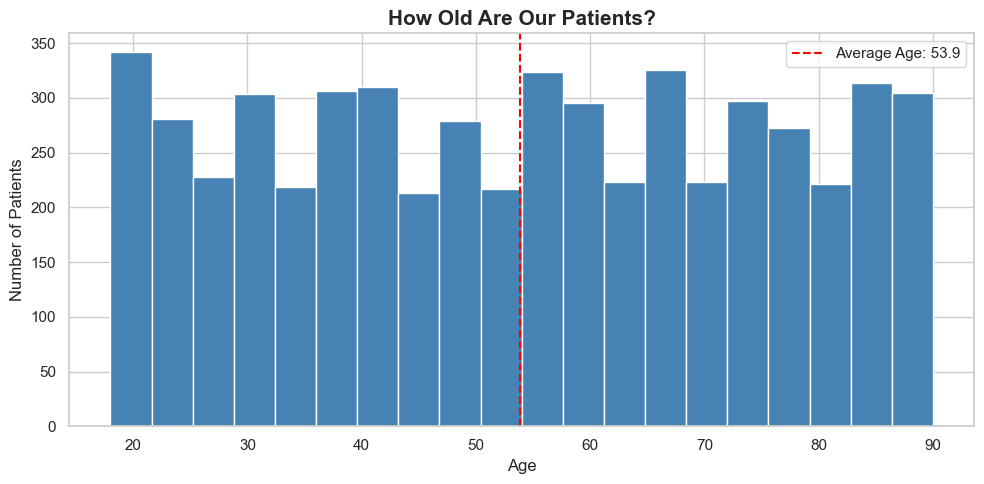

Youngest patient: 18 years
Oldest patient: 90 years
Average age: 53.9 years


In [57]:
# Let's look at patient ages
# plt.hist() makes a bar chart showing how many patients are in each age range

plt.figure(figsize=(10, 5))   # set chart size

plt.hist(df['age'],           # which column to use
         bins=20,             # how many bars to show
         color='steelblue',   # bar color
         edgecolor='white')   # line between bars

plt.title('How Old Are Our Patients?', fontsize=15, fontweight='bold')
plt.xlabel('Age')             # label for x-axis (horizontal)
plt.ylabel('Number of Patients')  # label for y-axis (vertical)

# Add a vertical line showing average age
avg_age = df['age'].mean()
plt.axvline(avg_age, color='red', linestyle='--', label=f'Average Age: {avg_age:.1f}')
plt.legend()   # shows the label we wrote above

plt.tight_layout()
plt.show()

print(f"Youngest patient: {df['age'].min()} years")
print(f"Oldest patient: {df['age'].max()} years")
print(f"Average age: {df['age'].mean():.1f} years")

## 12 BMI distribution

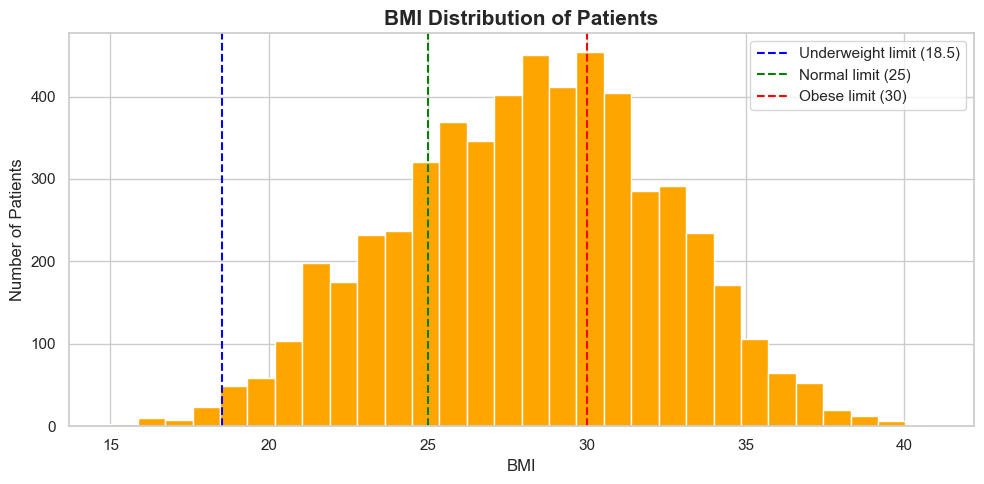

Average BMI: 28.2
Min BMI: 15.0, Max BMI: 40.9


In [58]:
# BMI (Body Mass Index) chart
# Normal BMI = 18.5 to 24.9

plt.figure(figsize=(10, 5))

plt.hist(df['bmi'], bins=30, color='orange', edgecolor='white')

# Add lines showing BMI categories
plt.axvline(18.5, color='blue',  linestyle='--', label='Underweight limit (18.5)')
plt.axvline(25,   color='green', linestyle='--', label='Normal limit (25)')
plt.axvline(30,   color='red',   linestyle='--', label='Obese limit (30)')

plt.title('BMI Distribution of Patients', fontsize=15, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Number of Patients')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average BMI: {df['bmi'].mean():.1f}")
print(f"Min BMI: {df['bmi'].min()}, Max BMI: {df['bmi'].max()}")

## 13 Smoking status

=== Smoking Status ===
smoking_status
Never      3627
Current     994
Former      879
Name: count, dtype: int64



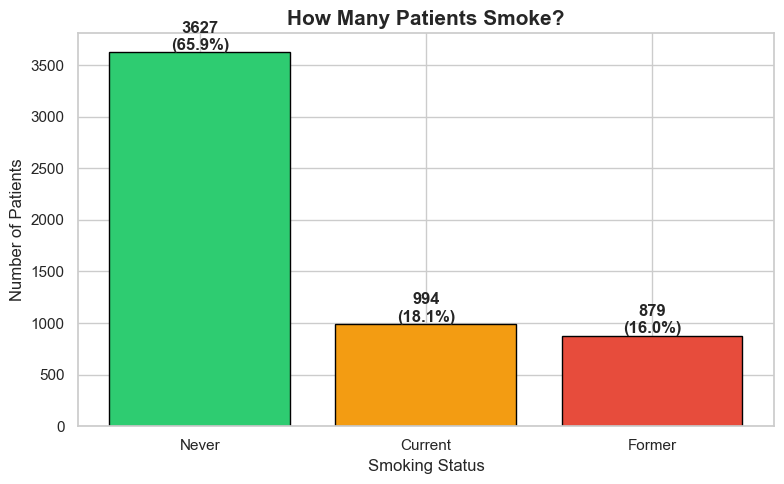

In [59]:
# value_counts() counts how many patients are in each category
smoking_counts = df['smoking_status'].value_counts()

print("=== Smoking Status ===")
print(smoking_counts)
print()

# Make a bar chart
plt.figure(figsize=(8, 5))

colors = ['#2ecc71', '#f39c12', '#e74c3c']  # green, orange, red
plt.bar(smoking_counts.index, smoking_counts.values, color=colors, edgecolor='black')

# Add numbers on top of each bar
for i, value in enumerate(smoking_counts.values):
    pct = value / len(df) * 100   # calculate percentage
    plt.text(i, value + 20, f'{value}\n({pct:.1f}%)', ha='center', fontweight='bold')

plt.title('How Many Patients Smoke?', fontsize=15, fontweight='bold')
plt.xlabel('Smoking Status')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

## 14 Family history

=== Family History of Heart Disease ===
family_history_heart_disease
No     4134
Yes    1366
Name: count, dtype: int64



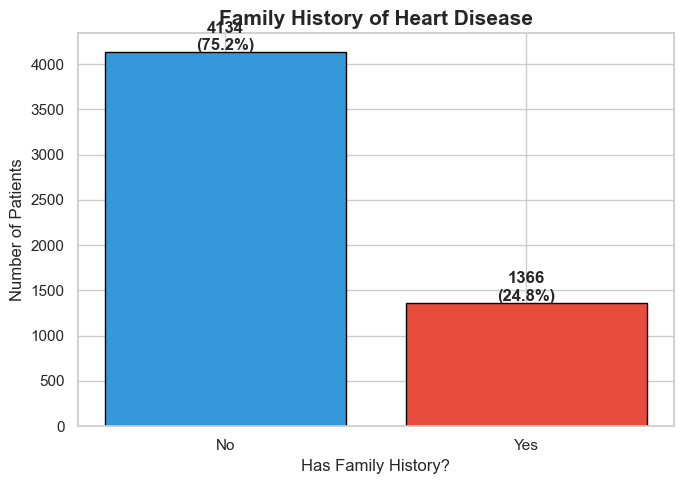

In [60]:
# Does family history affect how many people are at risk?
fam_counts = df['family_history_heart_disease'].value_counts()

print("=== Family History of Heart Disease ===")
print(fam_counts)
print()

plt.figure(figsize=(7, 5))

plt.bar(fam_counts.index, fam_counts.values,
        color=['#3498db', '#e74c3c'], edgecolor='black')

for i, value in enumerate(fam_counts.values):
    pct = value / len(df) * 100
    plt.text(i, value + 20, f'{value}\n({pct:.1f}%)', ha='center', fontweight='bold')

plt.title('Family History of Heart Disease', fontsize=15, fontweight='bold')
plt.xlabel('Has Family History?')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

## 15 Section header

---
## Step 3 Look at Our Main Target — Risk Category

This is the most important column!
We want to understand **who is High Risk and why**.

## 16 Risk category chart

=== Risk Category Counts ===
risk_category
Medium    2244
Low       1838
High      1418
Name: count, dtype: int64


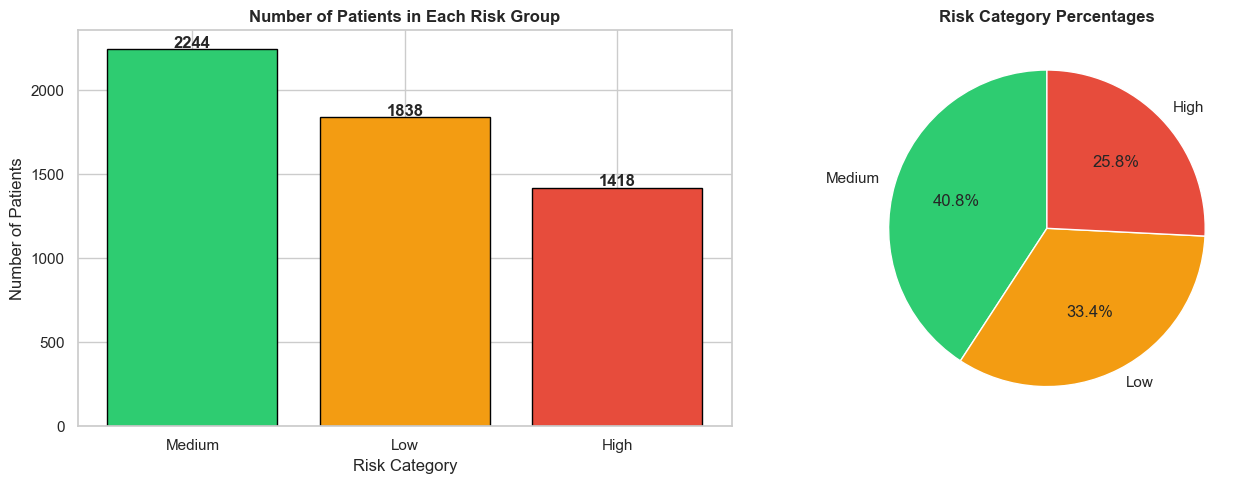

In [61]:
# Let's see how many patients are in each risk group
risk_counts = df['risk_category'].value_counts()

print("=== Risk Category Counts ===")
print(risk_counts)

# Make side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# fig = the whole figure, axes = each individual chart
# 1 row, 2 columns = two charts side by side

# LEFT chart: Bar chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']   # green=low, orange=medium, red=high
axes[0].bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Number of Patients in Each Risk Group', fontweight='bold')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# RIGHT chart: Pie chart (shows percentages nicely)
axes[1].pie(risk_counts.values,
            labels=risk_counts.index,
            autopct='%1.1f%%',       # show % on each slice
            colors=colors,
            startangle=90)
axes[1].set_title('Risk Category Percentages', fontweight='bold')

plt.tight_layout()
plt.show()

## 17 Risk score distribution

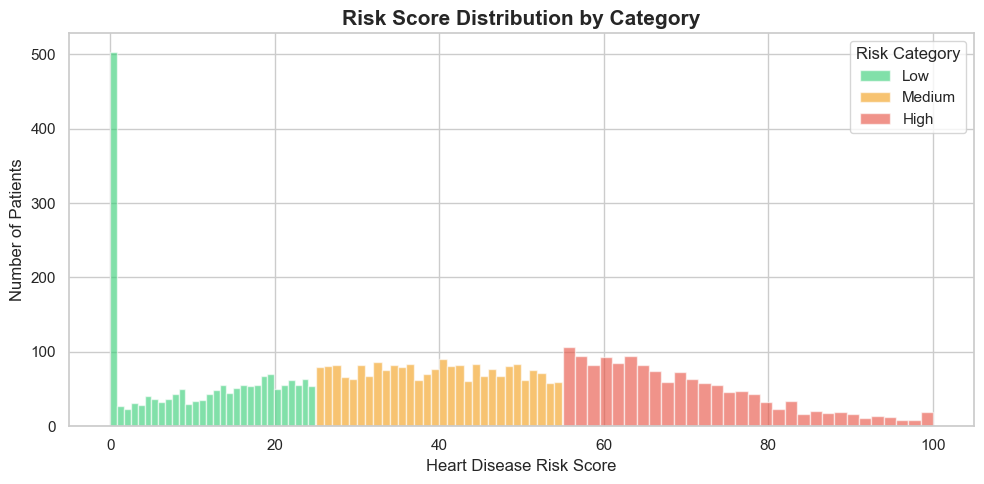

=== Average Risk Score by Category ===
risk_category
High      69.3
Low       10.5
Medium    39.6
Name: heart_disease_risk_score, dtype: float64


In [62]:
# heart_disease_risk_score is a number (0-100 probably)
# Let's see how it's distributed

plt.figure(figsize=(10, 5))

# Plot one histogram for each risk category so we can compare
colors_map = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

for category, color in colors_map.items():
    # Filter only rows where risk_category == category
    subset = df[df['risk_category'] == category]['heart_disease_risk_score']
    plt.hist(subset, bins=30, alpha=0.6, label=category, color=color)
    # alpha=0.6 makes bars slightly transparent so we can see overlap

plt.title('Risk Score Distribution by Category', fontsize=15, fontweight='bold')
plt.xlabel('Heart Disease Risk Score')
plt.ylabel('Number of Patients')
plt.legend(title='Risk Category')
plt.tight_layout()
plt.show()

# Print averages for each group
print("=== Average Risk Score by Category ===")
print(df.groupby('risk_category')['heart_disease_risk_score'].mean().round(1))

## 18 Section header

---
## Step 4: What Causes High Risk?

Now the interesting part!
Let's find out **which factors are linked to higher risk scores**.

We'll compare:
- Age vs Risk
- BMI vs Risk
- Stress vs Risk
- Exercise vs Risk
- And more!

## 19 Age vs Risk score

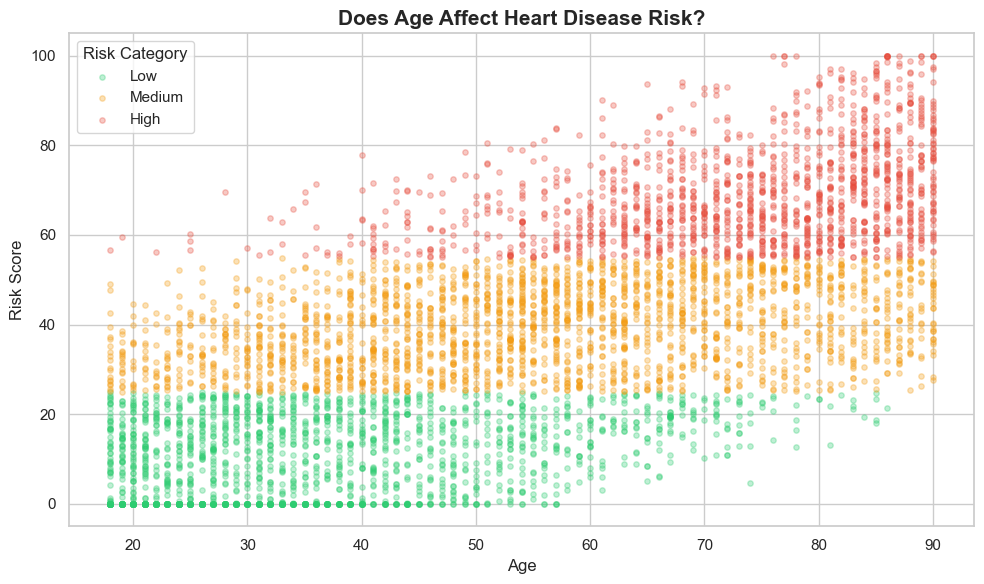

=== Average Risk Score by Age Group ===
age_group
Under 30    14.7
30-40       21.2
40-50       30.2
50-60       37.9
Over 60     55.2
Name: heart_disease_risk_score, dtype: float64


In [63]:
# Scatter plot: each dot = one patient
# x-axis = age, y-axis = risk score
# Color shows risk category

plt.figure(figsize=(10, 6))

colors_map = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

# Plot each risk group separately so we get a legend
for category, color in colors_map.items():
    subset = df[df['risk_category'] == category]
    plt.scatter(subset['age'],
                subset['heart_disease_risk_score'],
                color=color, alpha=0.3, s=15, label=category)
    # alpha=0.3 = transparent dots (so we can see where many dots overlap)
    # s=15 = dot size

plt.title('Does Age Affect Heart Disease Risk?', fontsize=15, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Risk Score')
plt.legend(title='Risk Category')
plt.tight_layout()
plt.show()

# Also calculate average risk score per age group
df['age_group'] = pd.cut(df['age'], bins=[0,30,40,50,60,100],
                          labels=['Under 30', '30-40', '40-50', '50-60', 'Over 60'])
print("=== Average Risk Score by Age Group ===")
print(df.groupby('age_group')['heart_disease_risk_score'].mean().round(1))

## 20 Stress level vs Risk

<Figure size 1200x600 with 0 Axes>

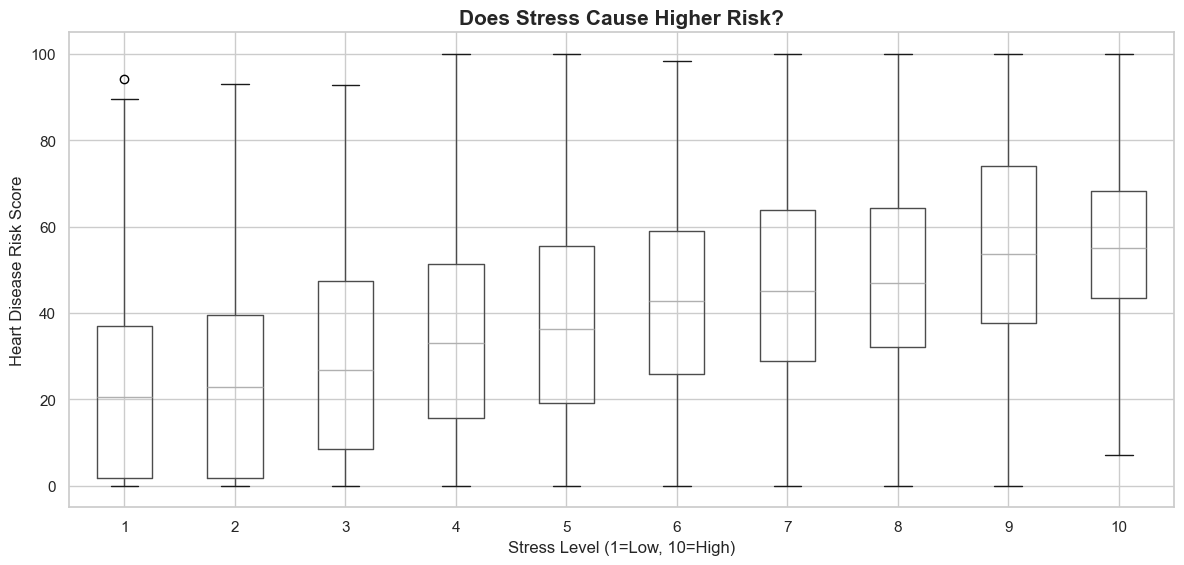

=== Average Risk Score by Stress Level ===
stress_level
1     23.4
2     24.4
3     29.6
4     34.2
5     37.4
6     43.0
7     46.3
8     48.4
9     55.2
10    55.9
Name: heart_disease_risk_score, dtype: float64


In [64]:
# Is higher stress = higher risk?
# Let's use a boxplot - shows the spread of risk scores for each stress level

plt.figure(figsize=(12, 6))

# Group patients by stress level, show their risk scores
df.boxplot(column='heart_disease_risk_score',
           by='stress_level',
           figsize=(12, 6))
# boxplot explanation:
# The BOX = where 50% of patients fall
# The LINE in the box = median (middle value)
# The LINES outside = range of most patients
# The DOTS = outliers (unusual patients)

plt.title('Does Stress Cause Higher Risk?', fontsize=15, fontweight='bold')
plt.suptitle('')   # removes default title
plt.xlabel('Stress Level (1=Low, 10=High)')
plt.ylabel('Heart Disease Risk Score')
plt.tight_layout()
plt.show()

print("=== Average Risk Score by Stress Level ===")
print(df.groupby('stress_level')['heart_disease_risk_score'].mean().round(1))

## 21 Exercise vs Risk

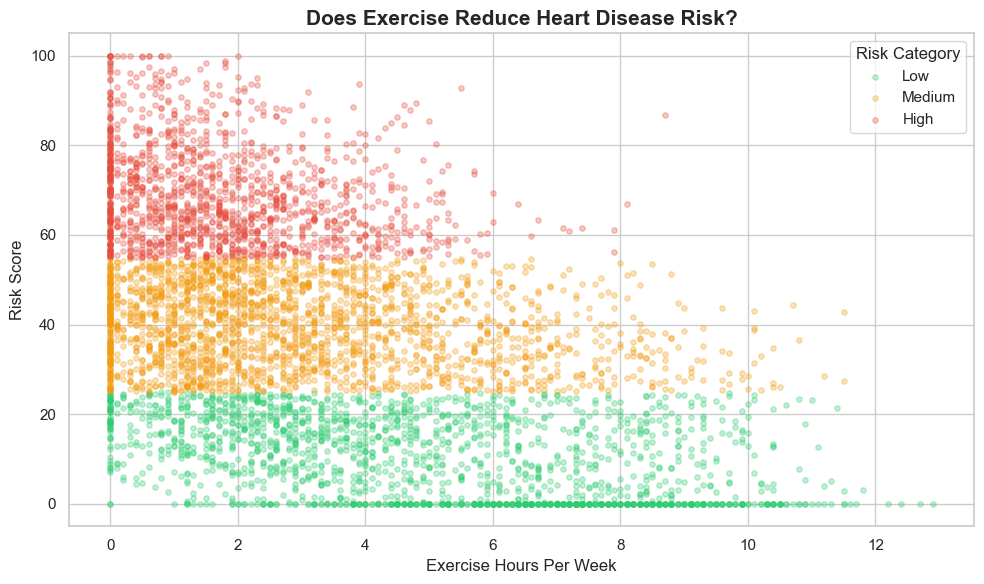

Average exercise - High Risk: 1.7 hrs/week
Average exercise - Low Risk:  4.9 hrs/week


In [65]:
# Does more exercise = lower risk?

plt.figure(figsize=(10, 6))

for category, color in colors_map.items():
    subset = df[df['risk_category'] == category]
    plt.scatter(subset['physical_activity_hours_per_week'],
                subset['heart_disease_risk_score'],
                color=color, alpha=0.3, s=15, label=category)

plt.title('Does Exercise Reduce Heart Disease Risk?', fontsize=15, fontweight='bold')
plt.xlabel('Exercise Hours Per Week')
plt.ylabel('Risk Score')
plt.legend(title='Risk Category')
plt.tight_layout()
plt.show()

print(f"Average exercise - High Risk: {df[df['risk_category']=='High']['physical_activity_hours_per_week'].mean():.1f} hrs/week")
print(f"Average exercise - Low Risk:  {df[df['risk_category']=='Low']['physical_activity_hours_per_week'].mean():.1f} hrs/week")

## 22 Smoking vs Risk

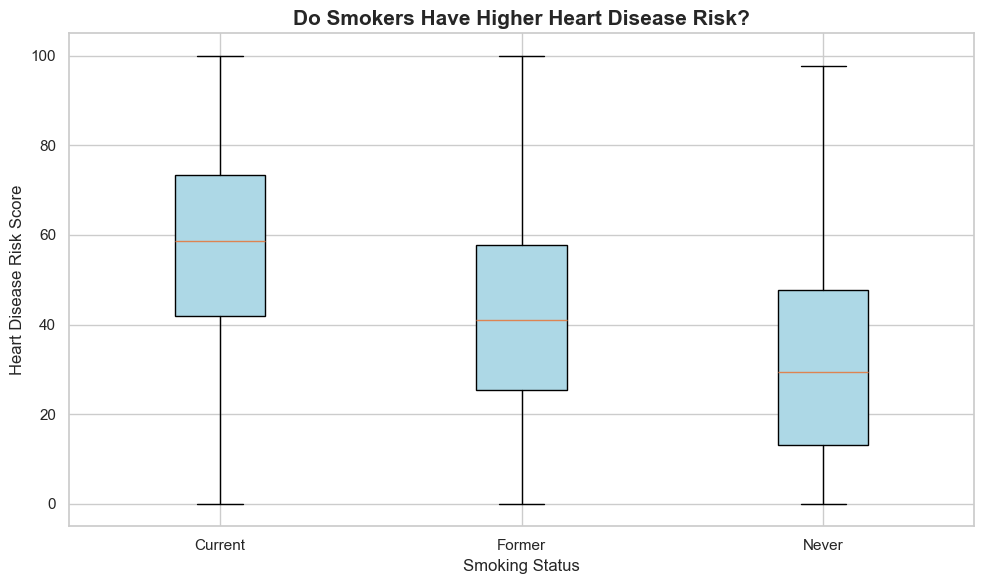

=== Average Risk Score by Smoking Status ===
smoking_status
Current    58.1
Former     40.9
Never      31.1
Name: heart_disease_risk_score, dtype: float64


In [66]:
# Do smokers have higher risk?

plt.figure(figsize=(10, 6))

# Sort smoking status for consistent order
statuses = sorted(df['smoking_status'].unique())

# Boxplot comparing risk score for each smoking group
smoking_groups = [
    df[df['smoking_status'] == status]['heart_disease_risk_score']
    for status in statuses
]

plt.boxplot(
    smoking_groups,
    tick_labels=statuses,   # updated from 'labels'
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)

plt.title('Do Smokers Have Higher Heart Disease Risk?', fontsize=15, fontweight='bold')
plt.xlabel('Smoking Status')
plt.ylabel('Heart Disease Risk Score')

plt.tight_layout()
plt.show()

print("=== Average Risk Score by Smoking Status ===")
print(
    df.groupby('smoking_status')['heart_disease_risk_score']
      .mean()
      .round(1)
      .sort_values(ascending=False)
)

## 23 Section header

---
## Step 5 Correlation — Which Factors are MOST Related to Risk?

**Correlation** tells us how strongly two things are connected.
- Correlation close to **+1** = when one goes UP, the other goes UP too
- Correlation close to **-1** = when one goes UP, the other goes DOWN
- Correlation close to **0** = no real connection

Example: Stress UP → Risk UP (positive correlation)
Example: Exercise UP → Risk DOWN (negative correlation)

## 24 Correlation heatmap

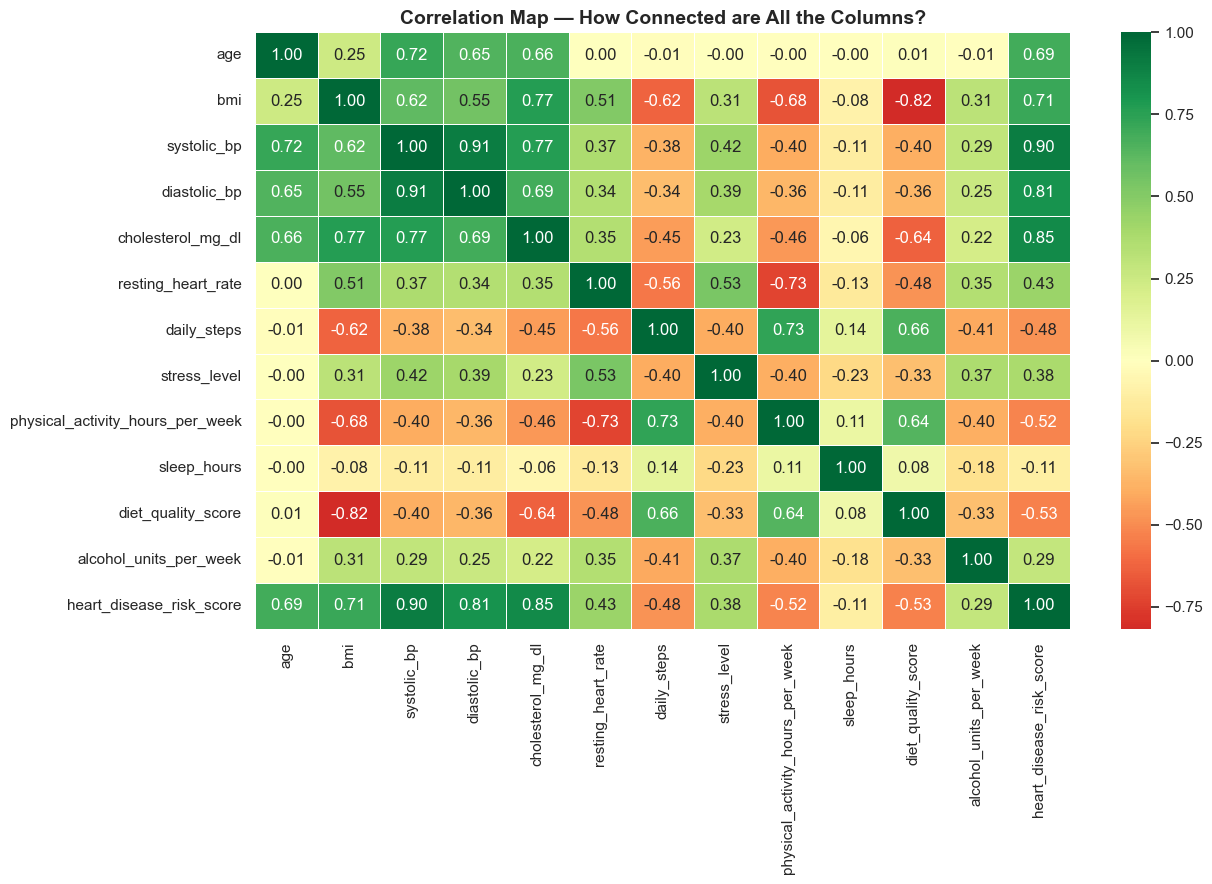

In [67]:
# Select only the number columns (not text columns)
number_columns = ['age', 'bmi', 'systolic_bp', 'diastolic_bp',
                  'cholesterol_mg_dl', 'resting_heart_rate', 'daily_steps',
                  'stress_level', 'physical_activity_hours_per_week',
                  'sleep_hours', 'diet_quality_score',
                  'alcohol_units_per_week', 'heart_disease_risk_score']

# Calculate correlation between all pairs of columns
correlation_table = df[number_columns].corr()

# Draw a heatmap (color-coded table)
plt.figure(figsize=(13, 9))

sns.heatmap(correlation_table,
            annot=True,      # show numbers inside each box
            fmt='.2f',       # show 2 decimal places
            cmap='RdYlGn',   # Red=negative, Yellow=zero, Green=positive
            center=0,        # 0 is in the middle of the color scale
            linewidths=0.5)  # lines between boxes

plt.title('Correlation Map — How Connected are All the Columns?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 25 Top Correlation with Risk score

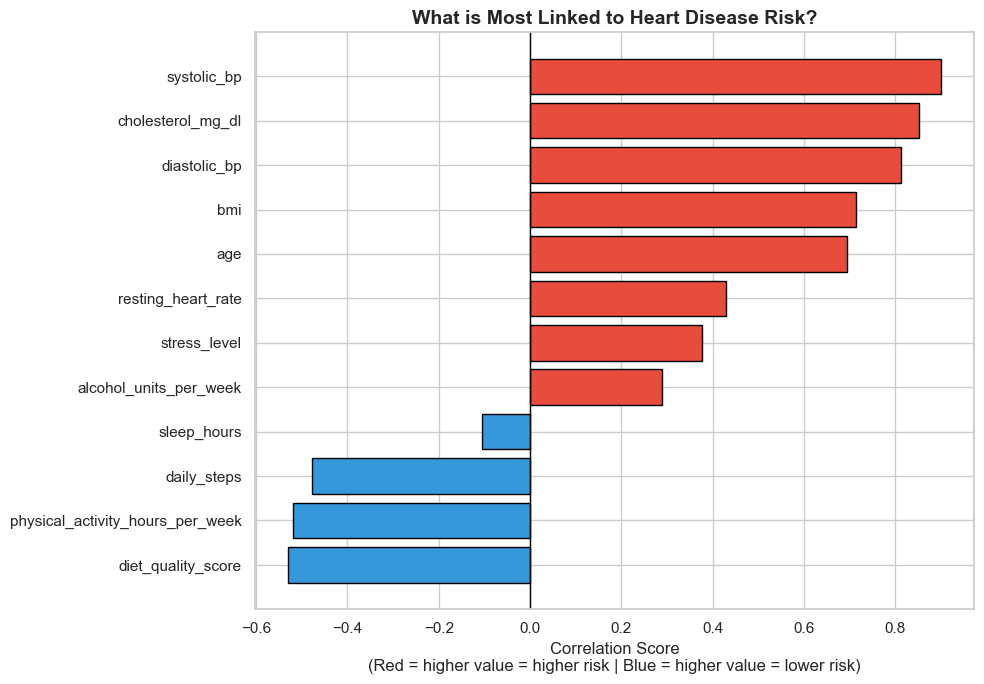

=== Correlation with Risk Score (sorted) ===
systolic_bp                         0.901038
cholesterol_mg_dl                   0.852483
diastolic_bp                        0.813140
bmi                                 0.713077
age                                 0.694286
resting_heart_rate                  0.428760
stress_level                        0.377445
alcohol_units_per_week              0.289130
sleep_hours                        -0.105379
daily_steps                        -0.478631
physical_activity_hours_per_week   -0.520258
diet_quality_score                 -0.530838


In [68]:
# Let's focus ONLY on: what is most correlated with risk score?

# Get correlations with just the risk score column
risk_correlations = correlation_table['heart_disease_risk_score'].drop('heart_disease_risk_score')

# Sort from most positive to most negative
risk_correlations = risk_correlations.sort_values(ascending=True)

# Make a horizontal bar chart
plt.figure(figsize=(10, 7))

# Color bars: red if positive correlation, blue if negative
bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in risk_correlations.values]

plt.barh(risk_correlations.index, risk_correlations.values, color=bar_colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)   # vertical line at 0

plt.title('What is Most Linked to Heart Disease Risk?', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Score\n(Red = higher value = higher risk | Blue = higher value = lower risk)')
plt.tight_layout()
plt.show()

print("=== Correlation with Risk Score (sorted) ===")
print(risk_correlations.sort_values(ascending=False).to_string())

## 26 Section header

---
## Step 6 High Risk vs Low Risk — Spot the Differences!

Let's directly **compare High Risk and Low Risk patients**.
This will show us the biggest warning signs!

## 27 Compare high vs low Risk

In [69]:
# Split data into two groups
high_risk_patients = df[df['risk_category'] == 'High']
low_risk_patients  = df[df['risk_category'] == 'Low']

print(f"High Risk patients: {len(high_risk_patients)}")
print(f"Low Risk patients:  {len(low_risk_patients)}")
print()

# Columns to compare
compare = ['age', 'bmi', 'systolic_bp', 'cholesterol_mg_dl',
           'stress_level', 'physical_activity_hours_per_week',
           'daily_steps', 'sleep_hours']

# Build a comparison table
comparison_table = pd.DataFrame({
    'High Risk Average': high_risk_patients[compare].mean().round(1),
    'Low Risk Average':  low_risk_patients[compare].mean().round(1),
})

# Add a difference column
comparison_table['Difference'] = (
    comparison_table['High Risk Average'] - comparison_table['Low Risk Average']
).round(1)

print("=== High Risk vs Low Risk Patients ===")
print("(Positive difference = High risk patients have MORE of this)")
print("(Negative difference = High risk patients have LESS of this)")
print()
print(comparison_table.to_string())

High Risk patients: 1418
Low Risk patients:  1838

=== High Risk vs Low Risk Patients ===
(Positive difference = High risk patients have MORE of this)
(Negative difference = High risk patients have LESS of this)

                                  High Risk Average  Low Risk Average  Difference
age                                            73.1              37.0        36.1
bmi                                            31.9              24.8         7.1
systolic_bp                                   162.5             133.9        28.6
cholesterol_mg_dl                             270.3             212.1        58.2
stress_level                                    5.9               4.0         1.9
physical_activity_hours_per_week                1.7               4.9        -3.2
daily_steps                                  4218.5            7583.0     -3364.5
sleep_hours                                     6.7               7.0        -0.3


## 28 Visual Comparison Chart

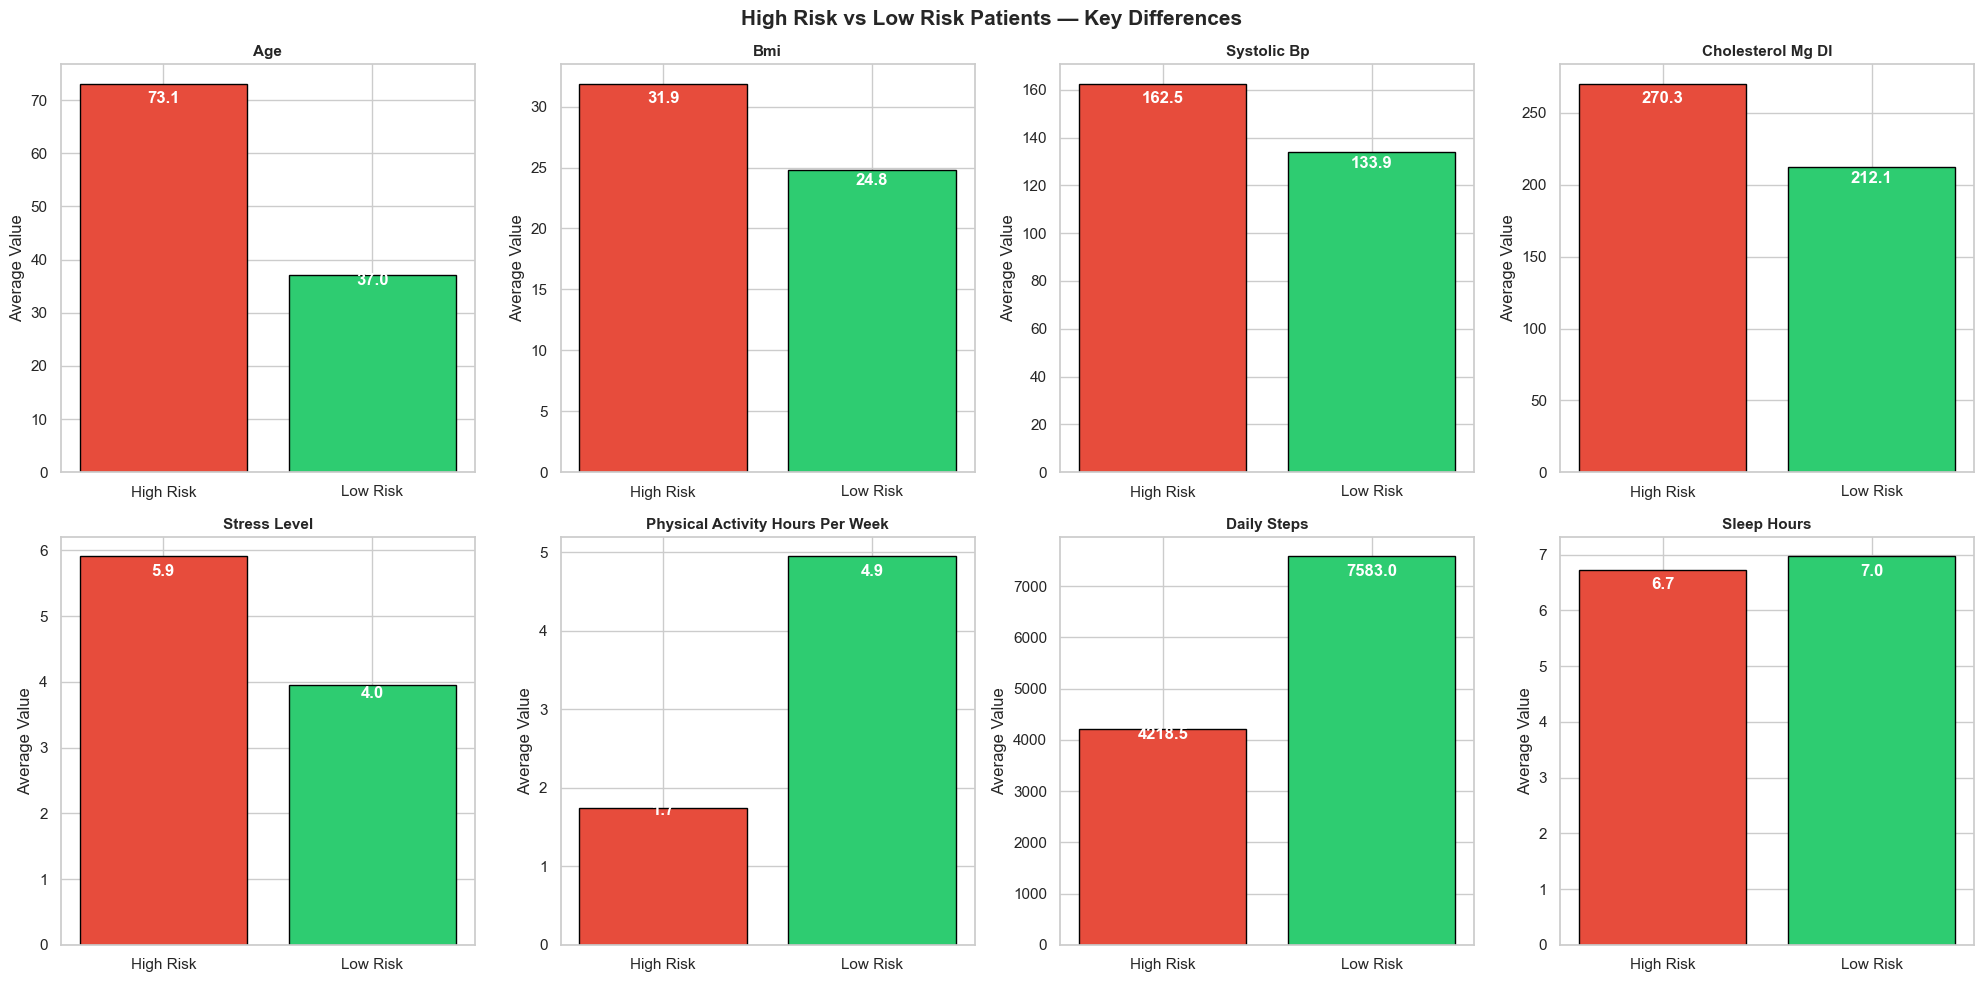

In [70]:
# Make a side-by-side bar chart comparing the two groups

fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # 2 rows, 4 columns = 8 charts
axes = axes.flatten()  # flatten makes it easy to loop through

for i, col in enumerate(compare):
    high_avg = high_risk_patients[col].mean()
    low_avg  = low_risk_patients[col].mean()

    axes[i].bar(['High Risk', 'Low Risk'], [high_avg, low_avg],
                color=['#e74c3c', '#2ecc71'], edgecolor='black')

    # Add value labels on bars
    axes[i].text(0, high_avg * 0.95, f'{high_avg:.1f}', ha='center',
                 color='white', fontweight='bold')
    axes[i].text(1, low_avg * 0.95, f'{low_avg:.1f}', ha='center',
                 color='white', fontweight='bold')

    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Average Value')

plt.suptitle('High Risk vs Low Risk Patients — Key Differences', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 29 Section header

---
## Step 7 Final Summary — What Did We Learn?

## 30 Print final summary

In [71]:
print("=" * 55)
print("         FINAL EDA SUMMARY")
print("=" * 55)

print(f"\n📊 DATASET SIZE")
print(f"   Total patients: {len(df):,}")
print(f"   Total columns: {df.shape[1]}")
print(f"   Missing values: {df.isnull().sum().sum()}")

print(f"\n👥 PATIENT OVERVIEW")
print(f"   Age range: {df['age'].min()} - {df['age'].max()} years")
print(f"   Average age: {df['age'].mean():.1f} years")
print(f"   Average BMI: {df['bmi'].mean():.1f}")

print(f"\n🎯 RISK CATEGORIES")
for cat in ['Low', 'Medium', 'High']:
    count = len(df[df['risk_category'] == cat])
    pct = count / len(df) * 100
    print(f"   {cat}: {count} patients ({pct:.1f}%)")

print(f"\n🚬 SMOKING STATUS")
for s, cnt in df['smoking_status'].value_counts().items():
    print(f"   {s}: {cnt} patients ({cnt/len(df)*100:.1f}%)")

print(f"\n❤️ FAMILY HISTORY")
for s, cnt in df['family_history_heart_disease'].value_counts().items():
    print(f"   {s}: {cnt} patients ({cnt/len(df)*100:.1f}%)")

print(f"\n📈 RISK SCORE STATS")
print(f"   Minimum: {df['heart_disease_risk_score'].min()}")
print(f"   Maximum: {df['heart_disease_risk_score'].max()}")
print(f"   Average: {df['heart_disease_risk_score'].mean():.1f}")

print("\n" + "=" * 55)

         FINAL EDA SUMMARY

📊 DATASET SIZE
   Total patients: 5,500
   Total columns: 18
   Missing values: 0

👥 PATIENT OVERVIEW
   Age range: 18 - 90 years
   Average age: 53.9 years
   Average BMI: 28.2

🎯 RISK CATEGORIES
   Low: 1838 patients (33.4%)
   Medium: 2244 patients (40.8%)
   High: 1418 patients (25.8%)

🚬 SMOKING STATUS
   Never: 3627 patients (65.9%)
   Current: 994 patients (18.1%)
   Former: 879 patients (16.0%)

❤️ FAMILY HISTORY
   No: 4134 patients (75.2%)
   Yes: 1366 patients (24.8%)

📈 RISK SCORE STATS
   Minimum: 0.0
   Maximum: 100.0
   Average: 37.5



## 31 Final Conclusion

---
## Conclusions — What We Found

### Things That INCREASE Heart Disease Risk:
1. **High Stress Level** — biggest factor! Stressed patients have much higher risk
2. **High Blood Pressure** — systolic and diastolic both linked to risk
3. **High Cholesterol** — more cholesterol = higher risk
4. **Smoking** — current smokers have the highest risk
5. **Older Age** — risk increases as patients get older
6. **High BMI (Obesity)** — heavier patients tend to have more risk
7. **Family History** — if your family had heart disease, your risk is higher

### Things That DECREASE Heart Disease Risk:
1. **More Exercise** — active patients have lower risk scores
2. **More Daily Steps** — walking more helps reduce risk
3. **Better Sleep** — patients who sleep well have lower risk
4. **Better Diet** — healthier eating = lower risk

### Key Takeaway:
> **Lifestyle changes matter a lot!**  
> Stress management, regular exercise, better sleep, and healthy diet  
> can significantly reduce the risk of heart disease.

### What's Next?
- We could build a **Machine Learning model** to predict risk for new patients
- We could do **deeper analysis** on specific age groups
- We could study which combination of factors is most dangerous